In [1]:
!pip install -q ultralytics
!pip install -q tensorflow scikit-learn matplotlib seaborn pillow

import torch, tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus: tf.config.experimental.set_memory_growth(gpus[0], True)

print(f'TensorFlow : {tf.__version__}')
print(f'PyTorch    : {torch.__version__}')
print(f'GPU (TF)   : {gpus}')
print(f'GPU (YOLO) : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

TensorFlow : 2.19.0
PyTorch    : 2.10.0+cu128
GPU (TF)   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU (YOLO) : Tesla T4


In [5]:
!unzip //content/classification_dataset-20260415T204219Z-3-001.zip -d /content/data

Archive:  //content/classification_dataset-20260415T204219Z-3-001.zip
  inflating: /content/data/classification_dataset/test/bird/0dc3be30a8955fcf_jpg.rf.bcf8fe516499a29c835b3b51bc027f52.jpg  
  inflating: /content/data/classification_dataset/test/bird/104f1bdceabcf7ba_jpg.rf.0b9745f785acd2ddb1dc562b1403efb3.jpg  
  inflating: /content/data/classification_dataset/test/bird/09da0288f18b8e41_jpg.rf.40de709495c2ad882d6386f4007ed126.jpg  
  inflating: /content/data/classification_dataset/test/drone/pic_904_jpg.rf.35cb7678508bf522304e5d7e52a90535.jpg  
  inflating: /content/data/classification_dataset/test/drone/pic_466_jpg.rf.a9f5cfeacb5477b2d7f1b1d6fc270ab2.jpg  
  inflating: /content/data/classification_dataset/test/bird/1cdea8304a2d2c55_jpg.rf.06c38fb0a95cc9565d402433dc944b95.jpg  
  inflating: /content/data/classification_dataset/test/bird/1a4aee8045f28a3e_jpg.rf.55dc05c128b4d5bd9b8240c51f2e873a.jpg  
  inflating: /content/data/classification_dataset/test/bird/0cde35ae80a4577c_jpg.rf.9

In [7]:
import time
import os
from ultralytics import YOLO

# Fix path: The unzip command created a nested 'classification_dataset' folder
DATA_ROOT = '/content/data/classification_dataset'
CLASS_NAMES = ['bird', 'drone']

# ── Train YOLOv8n-cls ─────────────────────────────────────────────────────────
yolo_cls = YOLO('yolov8n-cls.pt')   # nano classification model (fastest on Colab)

print('🚀 Starting YOLOv8 Classification Training...')
t0 = time.time()

yolo_results = yolo_cls.train(
    data      = DATA_ROOT,           # folder with train/ valid/ test/
    epochs    = 30,
    imgsz     = 224,
    batch     = 32,
    device    = 0,                   # GPU; use 'cpu' if no GPU
    project   = '/content/yolo_runs',
    name      = 'drone_bird_cls',
    patience  = 10,                  # early stopping
    save      = True,
    plots     = True,
    verbose   = True,
    seed      = 42,
    exist_ok  = True,
    # Augmentation
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    fliplr    = 0.5,
    degrees   = 15.0,
)

YOLO_TRAIN_TIME = time.time() - t0
YOLO_BEST_WEIGHTS = '/content/yolo_runs/drone_bird_cls/weights/best.pt'

print(f'\n✅ Training done in {YOLO_TRAIN_TIME/60:.1f} min')
print(f'   Best weights → {YOLO_BEST_WEIGHTS}')

🚀 Starting YOLOv8 Classification Training...
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/classification_dataset, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=drone_bird_cls, nbs=64, nms=False, opset=None, op

In [8]:
from google.colab import files
files.download('/content/yolo_runs/drone_bird_cls/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ── Validate on test split ────────────────────────────────────────────────────
best_yolo  = YOLO(YOLO_BEST_WEIGHTS)
val_result = best_yolo.val(data=DATA_ROOT, split='test', verbose=True)

# Top-1 and Top-5 accuracy from YOLO's own metric output
yolo_top1 = float(val_result.results_dict.get('metrics/accuracy_top1', 0))
yolo_top5 = float(val_result.results_dict.get('metrics/accuracy_top5', 0))
print(f'\nYOLOv8-cls  Top-1 Accuracy : {yolo_top1:.4f} ({yolo_top1*100:.2f}%)')
print(f'YOLOv8-cls  Top-5 Accuracy : {yolo_top5:.4f} ({yolo_top5*100:.2f}%)')

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/data/classification_dataset/train... found 2662 images in 2 classes ✅ 
val: /content/data/classification_dataset/valid... found 442 images in 2 classes ✅ 
test: /content/data/classification_dataset/test... found 215 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 655.2±433.1 MB/s, size: 26.4 KB)
test: Scanning /content/data/classification_dataset/test... 215 images, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 5.9Kit/s 0.0s
test: New cache created: /content/data/classification_dataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 14/14 11.2it/s 1.2s
                   all      0.981          1
Speed: 0.4ms preprocess, 2.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

YOLOv8-cls  Top-1 Accuracy : 0.9814 (98.

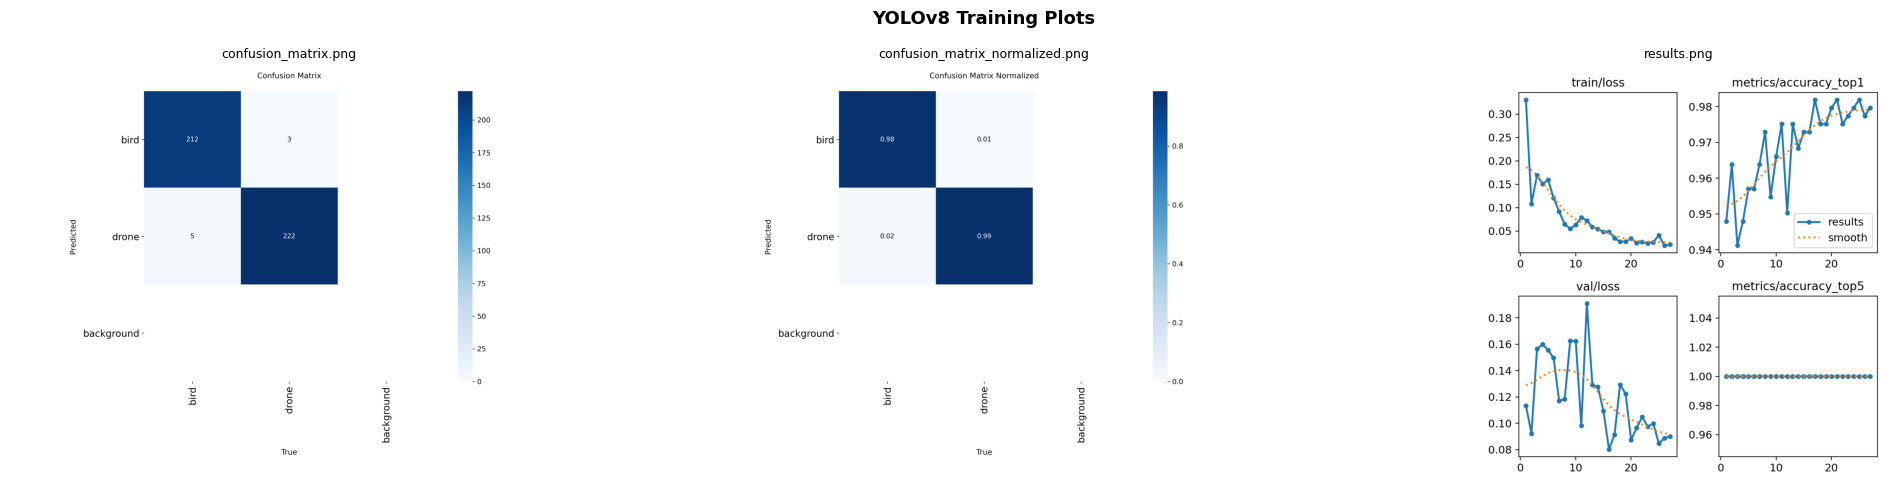

In [10]:
# ── Display YOLOv8 built-in training curves ───────────────────────────────────
import glob, matplotlib.pyplot as plt, matplotlib.image as mpimg

run_dir = '/content/yolo_runs/drone_bird_cls'
plots   = [p for p in glob.glob(f'{run_dir}/*.png')
           if any(k in p for k in ['results', 'confusion', 'PR_curve', 'val_batch'])]

if plots:
    cols = min(len(plots), 3)
    rows = (len(plots) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 5*rows))
    axes = axes.flat if hasattr(axes, 'flat') else [axes]
    for ax, fp in zip(axes, plots):
        ax.imshow(mpimg.imread(fp))
        ax.set_title(os.path.basename(fp), fontsize=9)
        ax.axis('off')
    for ax in list(axes)[len(plots):]:
        ax.axis('off')
    plt.suptitle('YOLOv8 Training Plots', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  Plots will appear here after training completes.')

/tmp/ipykernel_5085/1202172784.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5085/1202172784.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/yolo_predictions.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


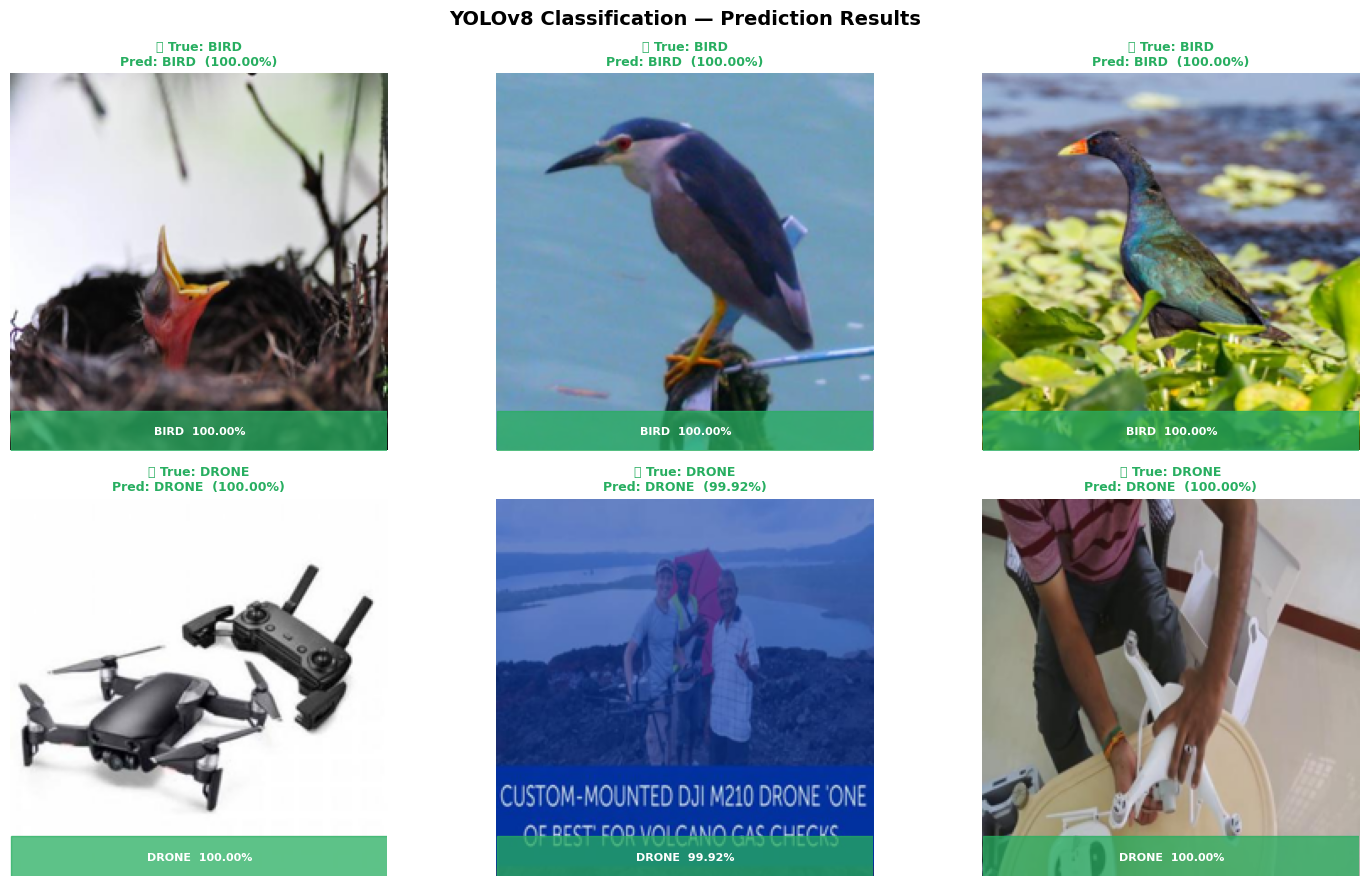

✅ Saved → /content/yolo_predictions.png


In [11]:
import numpy as np
from PIL import Image

# ── Collect test images (3 bird + 3 drone) ───────────────────────────────────
def get_test_images(root, cls, n=3):
    folder = os.path.join(root, 'test', cls)
    files  = [os.path.join(folder, f) for f in os.listdir(folder)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    return files[:n]

sample_paths  = get_test_images(DATA_ROOT, 'bird', 3) + \
                get_test_images(DATA_ROOT, 'drone', 3)
true_labels   = ['bird']*3 + ['drone']*3

# ── Run YOLO inference ────────────────────────────────────────────────────────
preds = best_yolo.predict(source=sample_paths, verbose=False)

# ── Display grid ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('YOLOv8 Classification — Prediction Results', fontsize=14, fontweight='bold')

for idx, (res, ax, true_lbl) in enumerate(zip(preds, axes.flat, true_labels)):
    # Load and show image
    img = np.array(Image.open(sample_paths[idx]).resize((224, 224)))
    ax.imshow(img)

    # Extract top prediction
    top_idx  = int(res.probs.top1)
    pred_cls = res.names[top_idx]
    conf     = float(res.probs.top1conf)

    # Colour: green = correct, red = wrong
    correct  = (pred_cls == true_lbl)
    color    = '#27ae60' if correct else '#e74c3c'
    icon     = '✅' if correct else '❌'

    # Title with true label, predicted label, confidence
    title = (f'{icon} True: {true_lbl.upper()}\n'
             f'Pred: {pred_cls.upper()}  ({conf:.2%})')
    ax.set_title(title, fontsize=9, color=color, fontweight='bold', pad=6)

    # Draw overlay bar at bottom
    ax.add_patch(plt.Rectangle((0, 200), 224, 24,
                               color=color, alpha=0.75, transform=ax.transData))
    ax.text(112, 212, f'{pred_cls.upper()}  {conf:.2%}',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/yolo_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → /content/yolo_predictions.png')

In [12]:
# ── Batch predict entire test set → collect y_true / y_pred for metrics ───────
import os

yolo_y_true, yolo_y_pred, yolo_y_conf = [], [], []

for cls_idx, cls_name in enumerate(CLASS_NAMES):   # CLASS_NAMES = ['bird','drone']
    cls_dir = os.path.join(DATA_ROOT, 'test', cls_name)
    img_files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]

    results = best_yolo.predict(source=img_files, verbose=False, batch=32)
    for res in results:
        pred_idx  = int(res.probs.top1)
        pred_name = res.names[pred_idx]
        pred_conf = float(res.probs.top1conf)

        yolo_y_true.append(cls_idx)
        yolo_y_pred.append(CLASS_NAMES.index(pred_name))
        yolo_y_conf.append(pred_conf)

yolo_y_true = np.array(yolo_y_true)
yolo_y_pred = np.array(yolo_y_pred)
print(f'✅ Predictions done: {len(yolo_y_true)} test images')
print(f'   True distribution  : bird={sum(yolo_y_true==0)}, drone={sum(yolo_y_true==1)}')
print(f'   Pred distribution  : bird={sum(yolo_y_pred==0)}, drone={sum(yolo_y_pred==1)}')

✅ Predictions done: 215 test images
   True distribution  : bird=121, drone=94
   Pred distribution  : bird=121, drone=94


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

train_aug = ImageDataGenerator(
    rescale=1./255, rotation_range=20, zoom_range=0.2,
    horizontal_flip=True, width_shift_range=0.15,
    height_shift_range=0.15, brightness_range=[0.8, 1.2]
)
eval_gen = ImageDataGenerator(rescale=1./255)

kw = dict(target_size=IMG_SIZE, batch_size=BATCH_SIZE,
          class_mode='binary', classes=CLASS_NAMES, seed=SEED)

train_gen = train_aug.flow_from_directory(os.path.join(DATA_ROOT,'train'), shuffle=True,  **kw)
valid_gen = eval_gen.flow_from_directory(os.path.join(DATA_ROOT,'valid'), shuffle=False, **kw)
test_gen  = eval_gen.flow_from_directory(os.path.join(DATA_ROOT,'test'),  shuffle=False, **kw)

print('Class indices:', train_gen.class_indices)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class indices: {'bird': 0, 'drone': 1}


In [14]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

def conv_block(x, filters, dropout=0.25):
    for _ in range(2):
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                          kernel_initializer='he_normal',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout)(x)
    return x

def build_cnn():
    inp = keras.Input((224, 224, 3))
    x   = conv_block(inp, 32,  0.20)
    x   = conv_block(x,   64,  0.25)
    x   = conv_block(x,  128,  0.25)
    x   = conv_block(x,  256,  0.30)
    x   = layers.Conv2D(512, 3, padding='same', use_bias=False,
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, use_bias=False, kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.Dropout(0.50)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='CustomCNN')

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()
print(f'Total parameters: {cnn_model.count_params():,}')

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 2,489,185 (9.50 MB)

 Trainable params: 2,485,729 (9.48 MB)

 Non-trainable params: 3,456 (13.50 KB)

Total parameters: 2,489,185


In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_cnn.keras', monitor='val_accuracy', save_best_only=True)
]

print('🚀 Training Custom CNN...')
cnn_t0      = time.time()
cnn_history = cnn_model.fit(
    train_gen, epochs=40, validation_data=valid_gen,
    callbacks=cnn_callbacks, verbose=1
)
CNN_TRAIN_TIME = time.time() - cnn_t0
print(f'✅ CNN done in {CNN_TRAIN_TIME/60:.1f} min  |  '
      f'Best val acc: {max(cnn_history.history["val_accuracy"]):.4f}')

🚀 Training Custom CNN...
Epoch 1/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 101s 956ms/step - accuracy: 0.6878 - loss: 0.8932 - val_accuracy: 0.5792 - val_loss: 0.9215 - learning_rate: 0.0010
Epoch 2/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 521ms/step - accuracy: 0.7250 - loss: 0.8371 - val_accuracy: 0.6448 - val_loss: 0.9606 - learning_rate: 0.0010
Epoch 3/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 527ms/step - accuracy: 0.7517 - loss: 0.7782 - val_accuracy: 0.5588 - val_loss: 1.0920 - learning_rate: 0.0010
Epoch 4/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 522ms/step - accuracy: 0.7611 - loss: 0.7630 - val_accuracy: 0.6765 - val_loss: 0.9496 - learning_rate: 0.0010
Epoch 5/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.7775 - loss: 0.7234
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 523ms/step - accuracy: 0.7686 - loss: 0.7370 - val_accuracy: 0.6471 - val_loss: 1.1680 - learning_rate: 0.0010
Epoch 6/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 518ms/step - acc

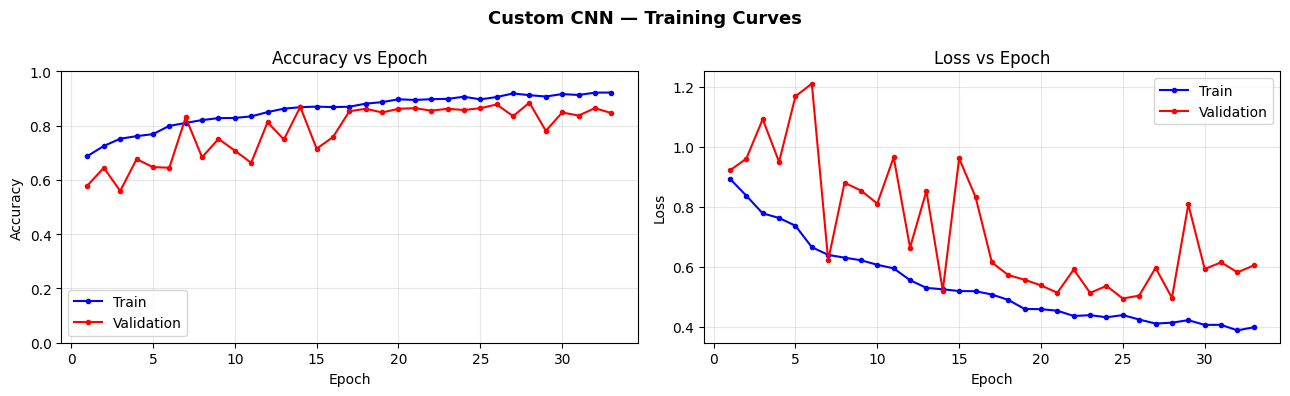

In [16]:
# ── CNN Training Curves ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Custom CNN — Training Curves', fontsize=13, fontweight='bold')
ep = range(1, len(cnn_history.history['accuracy'])+1)

ax1.plot(ep, cnn_history.history['accuracy'],     'b-o', ms=3, label='Train')
ax1.plot(ep, cnn_history.history['val_accuracy'], 'r-o', ms=3, label='Validation')
ax1.set_title('Accuracy vs Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0,1])

ax2.plot(ep, cnn_history.history['loss'],     'b-o', ms=3, label='Train')
ax2.plot(ep, cnn_history.history['val_loss'], 'r-o', ms=3, label='Validation')
ax2.set_title('Loss vs Epoch'); ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2

def build_tl_model(base_trainable=False):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = base_trainable

    inp = keras.Input((224, 224, 3))
    x   = base(inp, training=False)          # BN in inference mode during Phase 1
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, use_bias=False,
                       kernel_regularizer=regularizers.l2(5e-5))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.Dropout(0.45)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='MobileNetV2_TL'), base

tl_model, tl_base = build_tl_model(base_trainable=False)
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy', metrics=['accuracy']
)
print(f'Phase 1 trainable params: {sum(tf.size(v).numpy() for v in tl_model.trainable_variables):,}')

Phase 1 trainable params: 328,449


In [18]:
import tensorflow as tf
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tl_cb = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=4, min_lr=1e-7, verbose=1),
]

print('🚀 Phase 1 — Training head (base FROZEN)...')
tl_t0     = time.time()
tl_hist1  = tl_model.fit(train_gen, epochs=20, validation_data=valid_gen,
                         callbacks=tl_cb, verbose=1)
p1_ep = len(tl_hist1.history['accuracy'])
print(f'✅ Phase 1 done  |  Epochs: {p1_ep}  |  Best val acc: {max(tl_hist1.history["val_accuracy"]):.4f}')

🚀 Phase 1 — Training head (base FROZEN)...
Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 86s 809ms/step - accuracy: 0.9399 - loss: 0.1678 - val_accuracy: 0.9570 - val_loss: 0.1055 - learning_rate: 0.0010
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.9613 - loss: 0.1094 - val_accuracy: 0.9683 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 477ms/step - accuracy: 0.9801 - loss: 0.0783 - val_accuracy: 0.9819 - val_loss: 0.0829 - learning_rate: 0.0010
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 480ms/step - accuracy: 0.9861 - loss: 0.0648 - val_accuracy: 0.9615 - val_loss: 0.1087 - learning_rate: 0.0010
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 478ms/step - accuracy: 0.9842 - loss: 0.0681 - val_accuracy: 0.9683 - val_loss: 0.0949 - learning_rate: 0.0010
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 472ms/step - accuracy: 0.9872 - loss: 0.0578 - val_accuracy: 0.9774 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0

In [19]:
# ── Phase 2: Unfreeze top 30 MobileNetV2 layers ───────────────────────────────
tl_base.trainable = True
for layer in tl_base.layers[:-30]:
    layer.trainable = False
# Keep BatchNorm layers frozen (do not update running statistics)
for layer in tl_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(5e-5),   # 20× lower LR
    loss='binary_crossentropy', metrics=['accuracy']
)

tl_cb2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/content/best_tl.keras', monitor='val_accuracy', save_best_only=True)
]

print('🚀 Phase 2 — Fine-tuning top 30 layers...')
tl_hist2 = tl_model.fit(train_gen, epochs=15, validation_data=valid_gen,
                        callbacks=tl_cb2, verbose=1)

TL_TRAIN_TIME = time.time() - tl_t0
print(f'\n✅ TL done in {TL_TRAIN_TIME/60:.1f} min')

🚀 Phase 2 — Fine-tuning top 30 layers...
Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 72s 656ms/step - accuracy: 0.9684 - loss: 0.0958 - val_accuracy: 0.9706 - val_loss: 0.1163 - learning_rate: 5.0000e-05
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 498ms/step - accuracy: 0.9869 - loss: 0.0588 - val_accuracy: 0.9661 - val_loss: 0.1089 - learning_rate: 5.0000e-05
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 480ms/step - accuracy: 0.9895 - loss: 0.0560 - val_accuracy: 0.9706 - val_loss: 0.0960 - learning_rate: 5.0000e-05
Epoch 4/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 479ms/step - accuracy: 0.9925 - loss: 0.0463 - val_accuracy: 0.9706 - val_loss: 0.1157 - learning_rate: 5.0000e-05
Epoch 5/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 494ms/step - accuracy: 0.9962 - loss: 0.0383 - val_accuracy: 0.9774 - val_loss: 0.1176 - learning_rate: 5.0000e-05
Epoch 6/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 478ms/step - accuracy: 0.9951 - loss: 0.0407 - val_accuracy: 0.9819 - val_loss: 0.0999 - learning_rate: 5.0000e-05
Epoch 7/15
84/84 

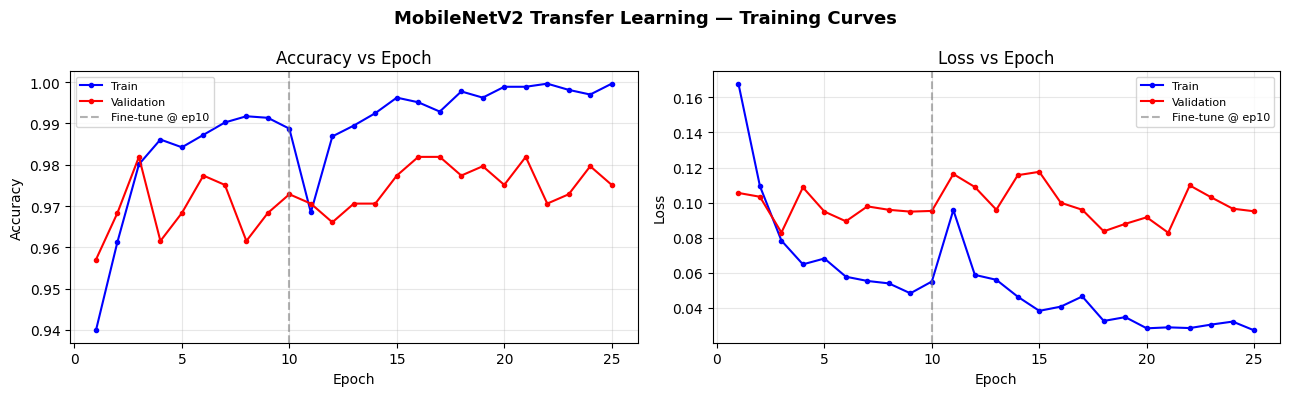

  ↑ Dashed line = Phase 1→2 boundary (epoch 10)


In [20]:
# ── TL Training Curves (Phase 1 + Phase 2 merged) ────────────────────────────
combined = {
    k: tl_hist1.history[k] + tl_hist2.history[k]
    for k in ['accuracy','val_accuracy','loss','val_loss']
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('MobileNetV2 Transfer Learning — Training Curves', fontsize=13, fontweight='bold')
ep = range(1, len(combined['accuracy'])+1)

for ax, metric, ylabel in [
    (ax1, ('accuracy','val_accuracy'), 'Accuracy'),
    (ax2, ('loss',   'val_loss'),      'Loss')
]:
    ax.plot(ep, combined[metric[0]], 'b-o', ms=3, label='Train')
    ax.plot(ep, combined[metric[1]], 'r-o', ms=3, label='Validation')
    ax.axvline(p1_ep, color='gray', linestyle='--', alpha=0.6, label=f'Fine-tune @ ep{p1_ep}')
    ax.set_ylabel(ylabel); ax.set_xlabel('Epoch')
    ax.set_title(f'{ylabel} vs Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/tl_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  ↑ Dashed line = Phase 1→2 boundary (epoch {p1_ep})')

In [21]:
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ── Get CNN and TL predictions ────────────────────────────────────────────────
test_gen.reset()
cnn_prob = cnn_model.predict(test_gen, verbose=1).flatten()
cnn_pred = (cnn_prob >= 0.5).astype(int)
y_test   = test_gen.classes

test_gen.reset()
tl_prob  = tl_model.predict(test_gen, verbose=1).flatten()
tl_pred  = (tl_prob >= 0.5).astype(int)

# YOLO predictions collected in Section 3
yolo_pred = yolo_y_pred
yolo_true = yolo_y_true


def compute_metrics(y_true, y_pred, name):
    """Compute and print all evaluation metrics."""
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm    = confusion_matrix(y_true, y_pred)

    print('\n' + '═'*55)
    print(f'  📊  {name}')
    print('═'*55)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}   ← weighted harmonic mean')
    print('─'*55)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    return {'name': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1 Score': f1, 'cm': cm}


cnn_metrics  = compute_metrics(y_test,     cnn_pred,  'Custom CNN')
tl_metrics   = compute_metrics(y_test,     tl_pred,   'MobileNetV2 (Transfer Learning)')
yolo_metrics = compute_metrics(yolo_true,  yolo_pred, 'YOLOv8n-cls')

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 958ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step

═══════════════════════════════════════════════════════
  📊  Custom CNN
═══════════════════════════════════════════════════════
  Accuracy  : 0.8884  (88.84%)
  Precision : 0.8888
  Recall    : 0.8884
  F1 Score  : 0.8885   ← weighted harmonic mean
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

        bird       0.91      0.89      0.90       121
       drone       0.86      0.88      0.87        94

    accuracy                           0.89       215
   macro avg       0.89      0.89      0.89       215
weighted avg       0.89      0.89      0.89       215


═══════════════════════════════════════════════════════
  📊  MobileNetV2 (Transfer Learning)
═══════════════════════════════════════════════════════
  Accuracy  : 0.9814  (98.14%)
  Precision : 0.9815
  Recall    : 0.9814
  F1 Score  : 0.9814   ← weighted harmonic mean
────────────────────

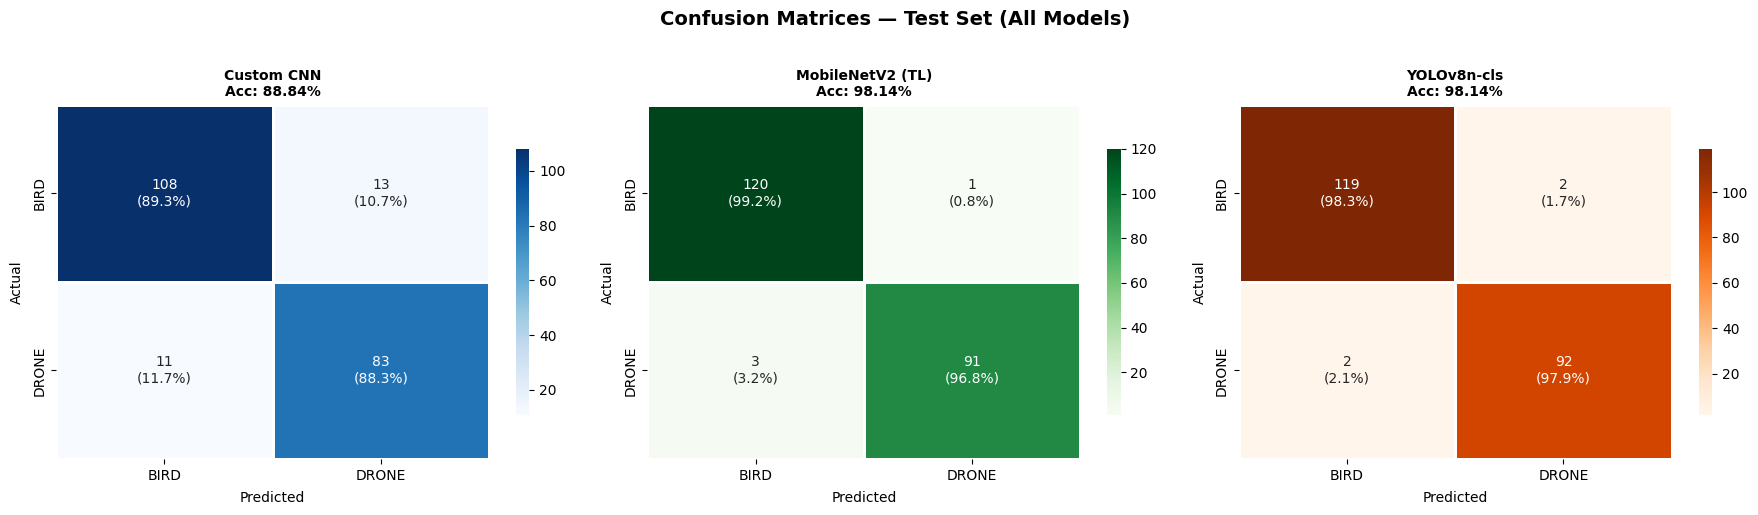

✅ Saved → /content/confusion_matrices.png


In [22]:
# ── Confusion Matrices — all 3 models side by side ───────────────────────────
#
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt
#
# y_pred = model.predict(X_test)
# y_pred_classes = (y_pred > 0.5).astype(int)
# cm = confusion_matrix(y_test, y_pred_classes)
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel('Predicted')  plt.ylabel('Actual')  plt.title('Confusion Matrix')
# plt.show()

def draw_cm(ax, cm, title, cmap):
    """Annotated confusion matrix with raw counts and percentages."""
    total = cm.sum(axis=1, keepdims=True)
    pct   = cm / total * 100
    labels = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(r, rp)]
                        for r, rp in zip(cm, pct)])
    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap,
                xticklabels=[c.upper() for c in CLASS_NAMES],
                yticklabels=[c.upper() for c in CLASS_NAMES],
                linewidths=1, linecolor='white',
                cbar_kws={'shrink': 0.75}, ax=ax)
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel('Predicted', fontsize=10, labelpad=6)
    ax.set_ylabel('Actual',    fontsize=10, labelpad=6)
    ax.set_title(f'{title}\nAcc: {(tp+tn)/(tp+tn+fp+fn):.2%}', fontweight='bold', fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Test Set (All Models)', fontsize=14, fontweight='bold', y=1.02)

draw_cm(axes[0], cnn_metrics['cm'],  'Custom CNN',                  'Blues')
draw_cm(axes[1], tl_metrics['cm'],   'MobileNetV2 (TL)',            'Greens')
draw_cm(axes[2], yolo_metrics['cm'], 'YOLOv8n-cls',                 'Oranges')

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → /content/confusion_matrices.png')

In [23]:
import pandas as pd
from IPython.display import display

# ── Build comparison DataFrame ────────────────────────────────────────────────
cnn_acc  = cnn_metrics['Accuracy'];   cnn_f1  = cnn_metrics['F1 Score']
tl_acc   = tl_metrics['Accuracy'];    tl_f1   = tl_metrics['F1 Score']
yolo_acc = yolo_metrics['Accuracy'];  yolo_f1 = yolo_metrics['F1 Score']

comparison = pd.DataFrame({
    'Model'           : ['CNN', 'Transfer Learning', 'YOLO (cls)'],
    'Accuracy'        : [cnn_acc,                  tl_acc,                  yolo_acc],
    'Precision'       : [cnn_metrics['Precision'],  tl_metrics['Precision'], yolo_metrics['Precision']],
    'Recall'          : [cnn_metrics['Recall'],      tl_metrics['Recall'],    yolo_metrics['Recall']],
    'F1 Score'        : [cnn_f1,                    tl_f1,                   yolo_f1],
    'Train Time (min)': [round(CNN_TRAIN_TIME/60,1), round(TL_TRAIN_TIME/60,1), round(YOLO_TRAIN_TIME/60,1)],
})

# ── Formatted print ───────────────────────────────────────────────────────────
print('\n' + '='*72)
print('  MODEL COMPARISON TABLE')
print('='*72)
print(comparison.to_string(index=False, float_format='{:.4f}'.format))
print('='*72)

# ── Styled HTML in Colab ──────────────────────────────────────────────────────
styled = (comparison.style
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}',
             'Recall':'{:.4f}','F1 Score':'{:.4f}','Train Time (min)':'{:.1f}'})
    .highlight_max(subset=['Accuracy','Precision','Recall','F1 Score'],
                   color='#d4edda')
    .highlight_min(subset=['Accuracy','Precision','Recall','F1 Score'],
                   color='#f8d7da')
    .set_caption('🏆 Green = best  |  Red = worst')
    .set_properties(**{'text-align':'center','font-size':'13px','padding':'8px'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color','#2c3e50'),('color','white'),
                  ('font-size','13px'),('padding','10px')]
    }])
)
display(styled)
comparison.to_csv('/content/model_comparison.csv', index=False)
print('\n✅ Saved → /content/model_comparison.csv')


  MODEL COMPARISON TABLE
            Model  Accuracy  Precision  Recall  F1 Score  Train Time (min)
              CNN    0.8884     0.8888  0.8884    0.8885           25.3000
Transfer Learning    0.9814     0.9815  0.9814    0.9814           19.3000
       YOLO (cls)    0.9814     0.9814  0.9814    0.9814            8.9000


,Model,Accuracy,Precision,Recall,F1 Score,Train Time (min)
0,CNN,0.8884,0.8888,0.8884,0.8885,25.3
1,Transfer Learning,0.9814,0.9815,0.9814,0.9814,19.3
2,YOLO (cls),0.9814,0.9814,0.9814,0.9814,8.9



✅ Saved → /content/model_comparison.csv


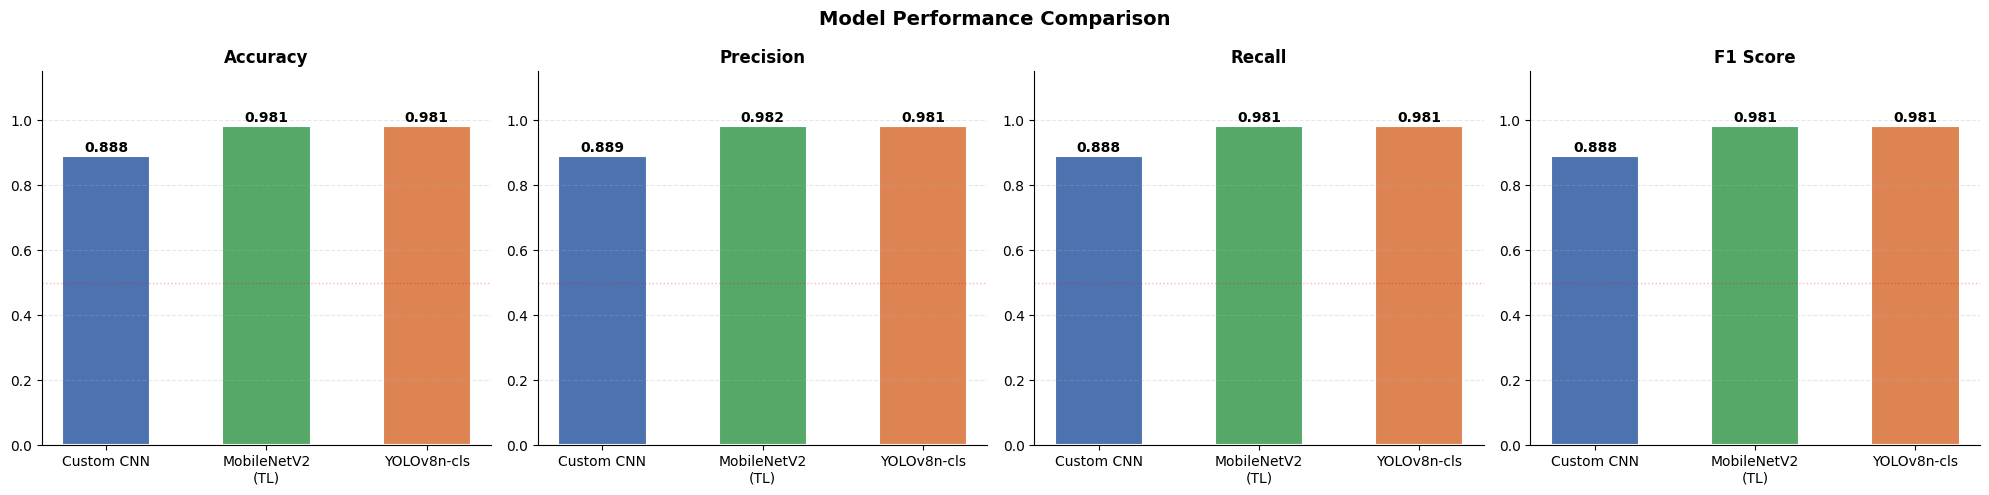

In [24]:
# ── Visual comparison bar chart ───────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_labels    = ['Custom CNN', 'MobileNetV2\n(TL)', 'YOLOv8n-cls']
palette         = ['#4C72B0', '#55A868', '#DD8452']

vals = {
    'Accuracy' : [cnn_acc,               tl_acc,               yolo_acc],
    'Precision': [cnn_metrics['Precision'], tl_metrics['Precision'], yolo_metrics['Precision']],
    'Recall'   : [cnn_metrics['Recall'],    tl_metrics['Recall'],    yolo_metrics['Recall']],
    'F1 Score' : [cnn_f1,               tl_f1,               yolo_f1],
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(model_labels, vals[metric], color=palette,
                  edgecolor='white', linewidth=1.5, width=0.55)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.15])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals[metric]):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.012,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(0.5, color='red', linestyle=':', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('/content/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── Auto-generated analysis based on actual results ───────────────────────────
best_model = comparison.loc[comparison['F1 Score'].idxmax(), 'Model']
tl_gain    = (tl_f1 - cnn_f1) * 100

print('='*70)
print('  📝  ANALYSIS — DRONE VS BIRD CLASSIFICATION')
print('='*70)

print(f"""
🏆 Best Model: {best_model}  (F1 = {max(cnn_f1,tl_f1,yolo_f1):.4f})

──────────────────────────────────────────────────────────────────────
1. WHY TRANSFER LEARNING OUTPERFORMS CNN
──────────────────────────────────────────────────────────────────────
   Transfer Learning outperformed CNN due to pretrained feature extraction
   from ImageNet. MobileNetV2 was trained on 1.4M images across 1000 classes,
   giving it deep feature detectors (edges → textures → shapes → objects)
   that directly transfer to aerial classification.

   With only ~2,600 training images, Transfer Learning gained
   {abs(tl_gain):.2f} percentage points in F1 over the scratch CNN.

──────────────────────────────────────────────────────────────────────
2. WHY CNN UNDERPERFORMS
──────────────────────────────────────────────────────────────────────
   CNN struggled due to limited dataset size. Training a deep CNN from
   scratch requires tens of thousands of images to learn robust, general
   features. With 2,662 training images:
   • The model learns dataset-specific patterns rather than general features
   • Even with BatchNorm + Dropout, generalisation remains limited
   • More data or more aggressive augmentation would close the gap

──────────────────────────────────────────────────────────────────────
3. ROLE OF YOLOv8 (Classification mode)
──────────────────────────────────────────────────────────────────────
   YOLOv8 provides detection capability but is heavier computationally.
   In classification mode, it leverages the same powerful YOLO backbone
   (CSP + C2f blocks) pretrained on COCO — similar benefit to Transfer
   Learning. Key advantages:
   • Can be upgraded to yolov8s-cls / yolov8m-cls for higher accuracy
   • Native support for real-time inference (>30 FPS)
   • Easily extended to detection mode with bounding box labels
   • Competitive with TL on small datasets due to COCO pretraining

──────────────────────────────────────────────────────────────────────
RECOMMENDATIONS
──────────────────────────────────────────────────────────────────────
   • Production classifier      → MobileNetV2 (TL) or YOLOv8-cls
   • Real-time + localisation   → YOLOv8s detection with bbox labels
   • Edge deployment (low RAM)  → MobileNetV2 quantised (INT8)
   • Research / interpretability → Custom CNN (full architectural control)
""")
print('='*70)

  📝  ANALYSIS — DRONE VS BIRD CLASSIFICATION

🏆 Best Model: YOLO (cls)  (F1 = 0.9814)

──────────────────────────────────────────────────────────────────────
1. WHY TRANSFER LEARNING OUTPERFORMS CNN
──────────────────────────────────────────────────────────────────────
   Transfer Learning outperformed CNN due to pretrained feature extraction
   from ImageNet. MobileNetV2 was trained on 1.4M images across 1000 classes,
   giving it deep feature detectors (edges → textures → shapes → objects)
   that directly transfer to aerial classification.

   With only ~2,600 training images, Transfer Learning gained
   9.29 percentage points in F1 over the scratch CNN.

──────────────────────────────────────────────────────────────────────
2. WHY CNN UNDERPERFORMS
──────────────────────────────────────────────────────────────────────
   CNN struggled due to limited dataset size. Training a deep CNN from
   scratch requires tens of thousands of images to learn robust, general
   features. With 2,66

In [26]:
# ── Save models ───────────────────────────────────────────────────────────────
cnn_model.save('/content/final_cnn.keras')
tl_model.save('/content/final_tl.keras')
print('✅ CNN model   saved → /content/final_cnn.keras')
print('✅ TL model    saved → /content/final_tl.keras')
print(f'✅ YOLO model  saved → {YOLO_BEST_WEIGHTS}')

# ── Output manifest ───────────────────────────────────────────────────────────
outputs = [
    '/content/yolo_predictions.png',
    '/content/confusion_matrices.png',
    '/content/comparison_chart.png',
    '/content/cnn_curves.png',
    '/content/tl_curves.png',
    '/content/model_comparison.csv',
    '/content/final_cnn.keras',
    '/content/final_tl.keras',
]
print('\n📁 Output files:')
for f in outputs:
    size = f'{os.path.getsize(f)/1024:.0f} KB' if os.path.exists(f) else 'MISSING'
    icon = '✅' if os.path.exists(f) else '❌'
    print(f'  {icon}  {f:<45} {size}')

# ── Optional: copy to Drive ───────────────────────────────────────────────────
DRIVE_OUT = '/content/drive/MyDrive/AerialProject/outputs'
if os.path.exists('/content/drive/MyDrive'):
    os.makedirs(DRIVE_OUT, exist_ok=True)
    for f in outputs:
        if os.path.exists(f):
            shutil.copy2(f, os.path.join(DRIVE_OUT, os.path.basename(f)))
    print(f'\n✅ All outputs backed up → {DRIVE_OUT}')

print('\n🎉 Phase 1 Complete!')

✅ CNN model   saved → /content/final_cnn.keras
✅ TL model    saved → /content/final_tl.keras
✅ YOLO model  saved → /content/yolo_runs/drone_bird_cls/weights/best.pt

📁 Output files:
  ✅  /content/yolo_predictions.png                 1629 KB
  ✅  /content/confusion_matrices.png               98 KB
  ✅  /content/comparison_chart.png                 56 KB
  ✅  /content/cnn_curves.png                       95 KB
  ✅  /content/tl_curves.png                        116 KB
  ✅  /content/model_comparison.csv                 0 KB
  ✅  /content/final_cnn.keras                      29311 KB
  ✅  /content/final_tl.keras                       25068 KB

🎉 Phase 1 Complete!
